=== SECOM Dataset ===
Shape: (1567, 590)
Pass/Fail counts:
label
-1    1463
 1     104
Name: count, dtype: int64

Missing values: 41951
Columns with >50% missing: 28

=== Steel Energy Dataset ===
Shape: (35040, 11)
Columns: ['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']
Missing values: 0


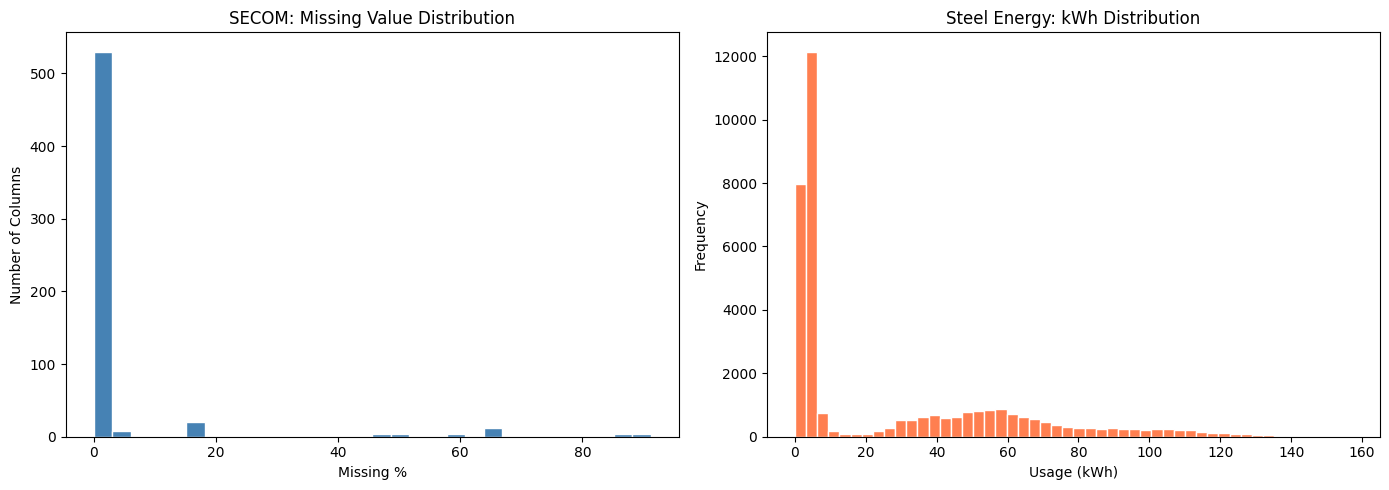


=== Cleaning Summary ===
SECOM: 590 -> 563 columns
Steel: (35040, 15) with new features
Files saved!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load raw data
secom = pd.read_csv('../data/raw/secom.data', sep=' ', header=None)
secom_labels = pd.read_csv('../data/raw/secom_labels.data', sep=' ', header=None)
secom_labels.columns = ['label', 'timestamp']
steel = pd.read_csv('../data/raw/steel_energy.csv')

print("=== SECOM Dataset ===")
print(f"Shape: {secom.shape}")
print(f"Pass/Fail counts:\n{secom_labels['label'].value_counts()}")
print(f"\nMissing values: {secom.isnull().sum().sum()}")
print(f"Columns with >50% missing: {((secom.isnull().sum()/len(secom))*100 > 50).sum()}")

print("\n=== Steel Energy Dataset ===")
print(f"Shape: {steel.shape}")
print(f"Columns: {list(steel.columns)}")
print(f"Missing values: {steel.isnull().sum().sum()}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

missing_pct = (secom.isnull().sum() / len(secom)) * 100
axes[0].hist(missing_pct, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('SECOM: Missing Value Distribution')
axes[0].set_xlabel('Missing %')
axes[0].set_ylabel('Number of Columns')

axes[1].hist(steel['Usage_kWh'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Steel Energy: kWh Distribution')
axes[1].set_xlabel('Usage (kWh)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../reports/figures/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Save cleaned data
secom_clean = secom.copy()
missing_pct = (secom_clean.isnull().sum() / len(secom_clean)) * 100
secom_clean = secom_clean.drop(columns=missing_pct[missing_pct > 50].index)
secom_clean = secom_clean.fillna(secom_clean.median())
secom_clean['label'] = secom_labels['label'].map({-1: 0, 1: 1})

steel['date'] = pd.to_datetime(steel['date'], dayfirst=True)
steel['hour'] = steel['date'].dt.hour
steel['month'] = steel['date'].dt.month
steel['is_weekend'] = (steel['WeekStatus'] == 'Weekend').astype(int)
steel['Load_Type_encoded'] = steel['Load_Type'].map({
    'Light_Load': 0, 'Medium_Load': 1, 'Maximum_Load': 2
})

secom_clean.to_csv('../data/processed/secom_clean.csv', index=False)
steel.to_csv('../data/processed/steel_clean.csv', index=False)

print("\n=== Cleaning Summary ===")
print(f"SECOM: {secom.shape[1]} -> {secom_clean.shape[1]} columns")
print(f"Steel: {steel.shape} with new features")
print("Files saved!")